In [7]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

In [5]:
data = pd.read_csv("train.csv")

In [6]:
data.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [39]:
data = np.array(data)
m, n = data.shape
np.random.shuffle(data)

data_dev = data[0:1000].T
Y_dev = data_dev[0]
X_dev = data_dev[1:n]

data_train = data[1000:m].T
Y_train = data_train[0]
X_train = data_train[1:n]

X_train = X_train / 255.
X_dev = X_dev / 255.

In [35]:
def init_params():
    W1 = np.random.randn(10, 784) * np.sqrt(2 / 784)
    b1 = np.zeros((10, 1))

    W2 = np.random.randn(10, 10) * np.sqrt(2 / 10)
    b2 = np.zeros((10, 1))

    return W1, b1, W2, b2

def ReLU(Z):
    return np.maximum(Z, 0)

def softmax(Z):
    A = np.exp(Z - np.max(Z, axis=0, keepdims=True))
    return A / np.sum(A, axis=0, keepdims=True)

def forward_prop(W1, b1, W2, b2, X):
    Z1 = W1.dot(X) + b1
    A1 = ReLU(Z1)
    Z2 = W2.dot(A1) + b2
    A2 = softmax(Z2)
    return Z1, A1, Z2, A2
    

def one_hot(Y):
    one_hot_Y = np.zeros((Y.size, 10))
    one_hot_Y[np.arange(Y.size), Y] = 1
    return one_hot_Y.T

def deriv_ReLU(Z):
    return Z > 0 

def backward_prop(Z1, A1, Z2, A2, W1, W2, X, Y):
    m = X.shape[1]

    one_hot_Y = one_hot(Y)

    dZ2 = A2 - one_hot_Y
    dW2 = (1 / m) * dZ2.dot(A1.T)
    db2 = (1 / m) * np.sum(dZ2, axis=1, keepdims=True)

    dZ1 = W2.T.dot(dZ2) * deriv_ReLU(Z1)
    dW1 = (1 / m) * dZ1.dot(X.T)
    db1 = (1 / m) * np.sum(dZ1, axis=1, keepdims=True)

    return dW1, db1, dW2, db2


def update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha):
    W1 = W1 - alpha * dW1
    b1 = b1 - alpha * db1
    W2 = W2 - alpha * dW2
    b2 = b2 - alpha * db2

    return W1, b1, W2, b2

In [36]:
def get_predictions(A2):
    return np.argmax(A2, 0)

def get_accuracy(predictions, Y):
    return np.sum(predictions == Y) / Y.size

def gradient_descent(X, Y, alpha, iterations):
    W1, b1, W2, b2 = init_params()
    
    for i in range(iterations):
        Z1, A1, Z2, A2 = forward_prop(W1, b1, W2, b2, X)
        dW1, db1, dW2, db2 = backward_prop(Z1, A1, Z2, A2, W1, W2, X, Y)
        W1, b1, W2, b2 = update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha)
        
        if i % 10 == 0:
            print("Iteration: ", i)
            print("Accuracy: ", get_accuracy(get_predictions(A2), Y))
    
    return W1, b1, W2, b2

In [41]:
W1, b1, W2, b2 = gradient_descent(
    X_train,
    Y_train,
    0.1,
    500
)

Iteration:  0
Accuracy:  0.13360975609756098
Iteration:  10
Accuracy:  0.462
Iteration:  20
Accuracy:  0.6228536585365854
Iteration:  30
Accuracy:  0.7183414634146341
Iteration:  40
Accuracy:  0.7641463414634146
Iteration:  50
Accuracy:  0.7885853658536586
Iteration:  60
Accuracy:  0.8051463414634147
Iteration:  70
Accuracy:  0.8167073170731707
Iteration:  80
Accuracy:  0.8264634146341463
Iteration:  90
Accuracy:  0.8349024390243902
Iteration:  100
Accuracy:  0.8422926829268292
Iteration:  110
Accuracy:  0.8486341463414634
Iteration:  120
Accuracy:  0.8537317073170732
Iteration:  130
Accuracy:  0.8585609756097561
Iteration:  140
Accuracy:  0.8615609756097561
Iteration:  150
Accuracy:  0.8652439024390244
Iteration:  160
Accuracy:  0.8685365853658537
Iteration:  170
Accuracy:  0.8711951219512195
Iteration:  180
Accuracy:  0.8734878048780488
Iteration:  190
Accuracy:  0.8762682926829268
Iteration:  200
Accuracy:  0.8781219512195122
Iteration:  210
Accuracy:  0.8798292682926829
Iteration: 

In [42]:
def make_predictions(X, W1, b1, W2, b2):
    _, _, _, A2 = forward_prop(W1, b1, W2, b2, X)
    predictions = get_predictions(A2)
    return predictions

def test_predictions(index, W1, b1, W2, b2):
    current_image = X_train[:, index, None]
    prediction = make_predictions(X_train[:, index, None], W1, b1, W2, b2)
    label = Y_train[index]
    print("Prediction: ", prediction)
    print("Label: ", label)
    
    current_image = current_image.reshape((28, 28)) * 255
    plt.gray()  
    plt.imshow(current_image, interpolation='nearest')
    plt.show()

Prediction:  [8]
Label:  8


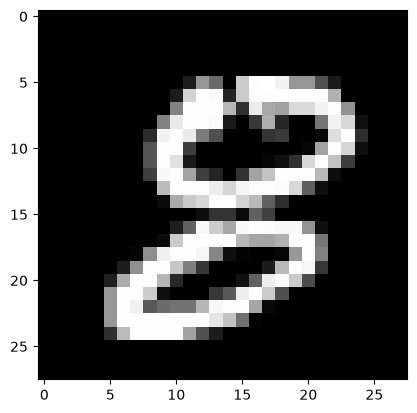

In [52]:
test_predictions(333, W1, b1, W2, b2)